Importing Libraries


In [13]:
import os
import re
import json
import html
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", 50)

print("Environment ready.")

Environment ready.


In [14]:
from pathlib import Path

DATA_PATH = Path("data/reviews.csv")

print(f"Dataset path: {DATA_PATH}")

Dataset path: data\reviews.csv


In [15]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}"
    )

print(f"Dataset found: {DATA_PATH}")

Dataset found: data\reviews.csv


In [16]:
df_raw = pd.read_csv(DATA_PATH)

print("Dataset shape:", df_raw.shape)

print("\nColumns:")
print(df_raw.columns.tolist())

display(df_raw.head())

Dataset shape: (832, 3)

Columns:
['category', 'productName', 'reviews']


,category,productName,reviews
0,wireless earbuds,"Wireless Earbuds, Bluetooth 5.3 Headphones HiFi Stereo 50H Playback LED Digital Display Ear Buds with ENC Noise Canceling Headset, IPX7 Waterproof Earphones for Gym/Running/Work(Black)",[]
1,wireless earbuds,"Wireless Earbuds, Bluetooth 5.3 Headphones HiFi Stereo 50H Playback LED Digital Display Ear Buds with ENC Noise Canceling Headset, IPX7 Waterproof Earphones for Gym/Running/Work（White）",[]
2,wireless earbuds,"MINISO MS217 Sleep Earbuds, Mini in-Ear Design for Side Sleepers, Real-Time AI Translation, 165 Languages & 9Translation Mode, Clear Calls and Music, Bluetooth 6.0, Ideal for Sleep/Work.Pink","[\n {\n ""review"": ""I really like the understated, stylish design, but what impressed me most is how comfortable they are to wear. That's something I really have to praise—I would already..."
3,wireless earbuds,"XIAOWTEK Wireless Earbuds, 2026 Bluetooth 5.4 Headphones Bass Stereo Ear Buds with Noise Cancelling Mic, LED Display in Ear Earphones 50H Playtime Ear Buds, IP7 Waterproof for Laptop Pad Phones White","[\n {\n ""review"": ""These headphones exceeded my expectations. They're very easy to connect via Bluetooth, and the sound is clear, with good volume and pleasant bass. The battery lasts a ..."
4,wireless earbuds,"Wireless Earbuds Bluetooth Headphones, 54H Playtime Stereo Over Ear Buds with ENC Noise Cancelling, LED Power Display, IPX7 Waterproof Sport Earphones with Earhooks for Running/Workouts (Black)","[\n {\n ""review"": ""I really love these earbuds. They have clear, powerful sound, connect easily via Bluetooth, and stay securely in place thanks to the ear hooks. The battery lasts a lon..."


In [17]:
required_columns = {
    "category",
    "productName",
    "reviews"
}

missing_columns = required_columns - set(df_raw.columns)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("All required columns are present.")

All required columns are present.


In [18]:
print(df_raw["reviews"].iloc[0])
print(type(df_raw["reviews"].iloc[0]))

[]
<class 'str'>


In [19]:
def parse_reviews(value):
    if pd.isna(value):
        return []

    if isinstance(value, list):
        return value

    text = str(value).strip()

    if not text or text == "[]":
        return []

    try:
        parsed = json.loads(text)
    except json.JSONDecodeError:
        try:
            parsed = json.loads(
                text.replace("\ufeff", "").strip()
            )
        except Exception:
            return []

    if not isinstance(parsed, list):
        return []

    return parsed

In [20]:
test_reviews = parse_reviews(
    df_raw["reviews"].iloc[0]
)

print("Number of reviews:", len(test_reviews))

display(test_reviews[:2])

Number of reviews: 0


[]

In [21]:
for i, value in enumerate(df_raw["reviews"]):
    parsed = parse_reviews(value)

    if parsed:
        print("First product containing reviews:", i)
        print("Number of reviews:", len(parsed))
        display(parsed[:2])
        break

First product containing reviews: 2
Number of reviews: 4


[{'review': "I really like the understated, stylish design, but what impressed me most is how comfortable they are to wear. That's something I really have to praise—I would already be very happy with them just for that. On top of the comfort, they also have a translation feature that I use from time to time. It's more than enough for everyday conversations."},
 {'review': "I really love these earbuds. I use them every day during my lunch break, and my ears never hurt even after wearing them for a long time. They also have a translation feature, which can definitely come in handy when traveling. With support for 165 languages, they're surprisingly versatile for the price. Overall, I think they're a great value."}]

In [22]:
records = []

for product_idx, row in df_raw.iterrows():
    reviews = parse_reviews(row["reviews"])

    for review_idx, review_obj in enumerate(reviews):

        if isinstance(review_obj, dict):
            review_text = review_obj.get("review", "")
        else:
            review_text = str(review_obj)

        records.append({
            "product_id": product_idx,
            "review_id": f"{product_idx}_{review_idx}",
            "category": row["category"],
            "productName": row["productName"],
            "review": review_text
        })

df_reviews = pd.DataFrame(records)

print("Flattened dataset shape:", df_reviews.shape)

display(df_reviews.head(10))

Flattened dataset shape: (9043, 5)


,product_id,review_id,category,productName,review
0,2,2_0,wireless earbuds,"MINISO MS217 Sleep Earbuds, Mini in-Ear Design for Side Sleepers, Real-Time AI Translation, 165 Languages & 9Translation Mode, Clear Calls and Music, Bluetooth 6.0, Ideal for Sleep/Work.Pink","I really like the understated, stylish design, but what impressed me most is how comfortable they are to wear. That's something I really have to praise—I would already be very happy with them just..."
1,2,2_1,wireless earbuds,"MINISO MS217 Sleep Earbuds, Mini in-Ear Design for Side Sleepers, Real-Time AI Translation, 165 Languages & 9Translation Mode, Clear Calls and Music, Bluetooth 6.0, Ideal for Sleep/Work.Pink","I really love these earbuds. I use them every day during my lunch break, and my ears never hurt even after wearing them for a long time. They also have a translation feature, which can definitely ..."
2,2,2_2,wireless earbuds,"MINISO MS217 Sleep Earbuds, Mini in-Ear Design for Side Sleepers, Real-Time AI Translation, 165 Languages & 9Translation Mode, Clear Calls and Music, Bluetooth 6.0, Ideal for Sleep/Work.Pink","These are now the earbuds I use most often every day. I really don't like noisy environments, and these have been a great fit for me. I can enjoy my music without being bothered by all the surroun..."
3,2,2_3,wireless earbuds,"MINISO MS217 Sleep Earbuds, Mini in-Ear Design for Side Sleepers, Real-Time AI Translation, 165 Languages & 9Translation Mode, Clear Calls and Music, Bluetooth 6.0, Ideal for Sleep/Work.Pink","These earbuds are incredibly small and comfortable, even when sleeping on my side. The soft silicone feels gentle and doesn't put any pressure on my ears. I often use them before bed to listen to ..."
4,3,3_0,wireless earbuds,"XIAOWTEK Wireless Earbuds, 2026 Bluetooth 5.4 Headphones Bass Stereo Ear Buds with Noise Cancelling Mic, LED Display in Ear Earphones 50H Playtime Ear Buds, IP7 Waterproof for Laptop Pad Phones White","These headphones exceeded my expectations. They're very easy to connect via Bluetooth, and the sound is clear, with good volume and pleasant bass. The battery lasts a long time, and the charging c..."
5,3,3_1,wireless earbuds,"XIAOWTEK Wireless Earbuds, 2026 Bluetooth 5.4 Headphones Bass Stereo Ear Buds with Noise Cancelling Mic, LED Display in Ear Earphones 50H Playtime Ear Buds, IP7 Waterproof for Laptop Pad Phones White","I’m very happy with these wireless earbuds. The sound quality is clear, with great bass, and the Bluetooth connection is quick and stable. They are comfortable to wear for long periods, and the LE..."
6,3,3_2,wireless earbuds,"XIAOWTEK Wireless Earbuds, 2026 Bluetooth 5.4 Headphones Bass Stereo Ear Buds with Noise Cancelling Mic, LED Display in Ear Earphones 50H Playtime Ear Buds, IP7 Waterproof for Laptop Pad Phones White","These wireless earbuds exceeded my expectations. The sound is clear, with deep bass and crisp highs, making music and calls sound great. They pair quickly with Bluetooth 5.4 and maintain a stable ..."
7,3,3_3,wireless earbuds,"XIAOWTEK Wireless Earbuds, 2026 Bluetooth 5.4 Headphones Bass Stereo Ear Buds with Noise Cancelling Mic, LED Display in Ear Earphones 50H Playtime Ear Buds, IP7 Waterproof for Laptop Pad Phones White","I really like these wireless earbuds. They connect quickly via Bluetooth, the sound is clear, and the volume is great. They are comfortable to wear, and the charging case is compact and easy to ca..."
8,3,3_4,wireless earbuds,"XIAOWTEK Wireless Earbuds, 2026 Bluetooth 5.4 Headphones Bass Stereo Ear Buds with Noise Cancelling Mic, LED Display in Ear Earphones 50H Playtime Ear Buds, IP7 Waterproof for Laptop Pad Phones White","Great sound quality and excellent battery life!I was pleasantly surprised by the quality of these S66 wireless earbuds. They connected to my phone quickly and easily, and the sound is clear with g..."
9,3,3_5,wireless earbuds,"XIAOWTEK Wireless Earbuds, 2026 Bluetooth 5.4 Headphones Bass Stereo Ear Buds with Noise Cancelling

In [23]:
FLAT_REVIEWS_PATH = Path("artifacts/feature_b/flattened_reviews.csv")

FLAT_REVIEWS_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

df_reviews.to_csv(
    FLAT_REVIEWS_PATH,
    index=False
)

print(f"Flattened reviews saved to: {FLAT_REVIEWS_PATH}")

Flattened reviews saved to: artifacts\feature_b\flattened_reviews.csv


In [24]:
print("Missing values:")
display(df_reviews.isna().sum().to_frame("missing"))

Missing values:


,missing
product_id,0
review_id,0
category,0
productName,0
review,0


In [25]:
empty_reviews = (
    df_reviews["review"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("Empty reviews:", empty_reviews)

Empty reviews: 0


In [26]:
duplicate_reviews = (
    df_reviews["review"]
    .duplicated()
    .sum()
)

print("Duplicate review texts:", duplicate_reviews)

Duplicate review texts: 875


In [27]:
df_reviews["review_chars"] = (
    df_reviews["review"]
    .fillna("")
    .str.len()
)

df_reviews["review_words"] = (
    df_reviews["review"]
    .fillna("")
    .str.split()
    .str.len()
)

display(
    df_reviews[
        ["review_chars", "review_words"]
    ].describe()
)

,review_chars,review_words
count,9043.000000,9043.000000
mean,572.628442,103.766781
std,819.043360,147.493082
min,3.000000,1.000000
25%,117.000000,21.000000
50%,302.000000,56.000000
75%,691.000000,125.000000
max,17970.000000,3241.000000


Shortest Reviews


In [28]:
display(
    df_reviews[
        ["review_id", "productName", "review",
         "review_chars", "review_words"]
    ]
    .sort_values("review_chars")
    .head(20)
)

,review_id,productName,review,review_chars,review_words
8533,783_7,"COOPER ChatStand Sturdy Cell Phone Holder, iPhone Stand for Desk, Recording",Top,3,1
2387,219_12,"PHILIPS Sonicare 1100 Rechargeable Electric Toothbrush, 1 Brush Head, White",Good,4,1
7469,690_6,"Bath & Body Works 3-Wick Candle, Champagne Toast, Soy Wax Blend",Good,4,1
489,48_8,"AULA F75 Pro Wireless Mechanical Keyboard,75% Hot Swappable Custom Keyboard with Knob,RGB Backlit,Pre-lubed Reaper Switches,Side Printed PBT Keycaps,2.4GHz/USB-C/BT5.0 Mechanical Gaming Keyboards",Good,4,1
2952,270_11,"Samsung 14"" Galaxy Chromebook Go Laptop PC Computer, Intel Celeron N4500 Processor, 4GB RAM, 64GB Storage, ChromeOS, XE340XDA-KA2US, Student Laptop, Silver",Good,4,1
6202,574_10,Next Level Apparel Mens N6210,Good,4,1
6738,625_10,New Balance Women's 327,Good,4,1
8733,802_8,"Zager Easy Play Acoustic Guitar Strings – Fits Martin, Taylor, Yamaha, Fender & Gibson Guitars – Easy on Fingers, Anti-Rust, Warm Rich Tone",Good,4,1
3147,288_8,Astercook Knife Set for Kitchen with Block and Sharpener 15pcs German,Fake,4,1
800,75_8,"SAMSUNG Galaxy FIT 3 [2024] 1.6"" AMOLED Display | 14 Days Battery Life | 100+ Watchfaces | 100+ Exercise Modes | International Model - (Gray)",nice,4,1


Longest Reviews

In [29]:
display(
    df_reviews[
        ["review_id", "productName", "review",
         "review_chars", "review_words"]
    ]
    .sort_values("review_chars", ascending=False)
    .head(10)
)

,review_id,productName,review,review_chars,review_words
2056,192_11,"Instant Pot Duo 6 Qt 7-in-1 Electric Pressure Cooker, Stainless Steel","•• Why I Bought The Instant Pot (and why you probably should, too) ••In this review, I'll cover safety mechanisms and info, how to use the instant pot, minimum liquid requirements, along with a wh...",17970,3241
4190,382_7,"Breville BES870XL Barista Express Espresso Machine, Brushed Stainless Steel","This is the first espresso machine I've ever owned. I purchased it this Spring (2020) because, like many of you, I needed to stop going out. I didn't know much about home brewing espresso, but I...",10572,1868
3133,287_7,"Bose SoundLink Max Bluetooth Speaker - Portable Wireless Party Speaker, IP67 Waterproof, Rope Handle, Up to 20 Hours of Playtime, USB-C, Built-in 3.5mm AUX Input, Black","*FIRST IMPRESSIONS:Listening to music as it comes out of the box, I had two impressions,something is missing from the music and what is that painful squeael in the treble area. while they may so...",10523,1837
360,37_0,"Rosonway 7 Ports Powered USB 3.2/USB C Hub 10Gbps with 4 USB-C 3.2, 3 USB-A 3.2 Ports, 3.3ft Cable and 36W(12V/3A) Power Adapter, Aluminum USB Splitter for Laptop, RSH-H7C4","I have a LITE-ON USB 2.0 External CD/DVD Writer Model eUAU108, manufactured in 2013, with an attached cable that is slightly less than 4 inches long. This model was an improvement over prior mod...",9581,1681
2077,194_7,"Instant Pot Duo 7-in-1 Mini Electric Pressure Cooker, Slow Rice Cooker, Steamer, Sauté, Yogurt Maker, Warmer & Sterilizer, Includes Free App with over 1900 Recipes, Stainless Steel, 3 Quart","FURTHER UPDATE - It's now August 2017 and I've had my IP for almost 2.5 years. I got Pork Chile Verde dialed in, using the recipe from Serious Eats. I add a diced fresh jalapeño and some lime juic...",9437,1715
3022,277_7,"Ortizan X10 Portable Bluetooth Speaker (1st Gen), IPX7 Waterproof, Wireless","Update 3: I am not doing ""never ending updates"" but just typing this to say that the issue STILL hasn't come back. The one thing I have noticed is that i am getting NO WHERE NEAR the ""30 hour pla...",9298,1814
363,37_3,"Rosonway 7 Ports Powered USB 3.2/USB C Hub 10Gbps with 4 USB-C 3.2, 3 USB-A 3.2 Ports, 3.3ft Cable and 36W(12V/3A) Power Adapter, Aluminum USB Splitter for Laptop, RSH-H7C4",I have been in IT long enough to know that a USB hub is one of those products that sounds simple on paper but has a surprisingly wide range of quality in practice. I have also been burned enough t...,7717,1348
4031,369_5,"Keurig K-Classic Single Serve K-Cup Pod Coffee Maker, with 3 Brew Sizes, 48oz Removable Reservoir, Black","***Updates are located at the bottom of this review.******Original Review***Up until recently, I had never been much of a coffee drinker except for the occasional seasonal flavored latte drinks bu...",7562,1423
4187,382_4,"Breville BES870XL Barista Express Espresso Machine, Brushed Stainless Steel",Update 9/19/2020-- The machine continues to may fantastic coffee. Enjoying some right now. One of our most used small appliances during the pandemic. Will never go back to SB again. It compare...,7071,1285
4916,453_1,"MATEIN Travel Laptop Backpack, 15.6 Inch College School Computer Bag, Grey",We bought this three years ago for our ELDEST. A boy rough and tumble teenager carried it through Middle School with 20 pounds of weight and a stainless steel water bottle it survived three years ...,7028,1371


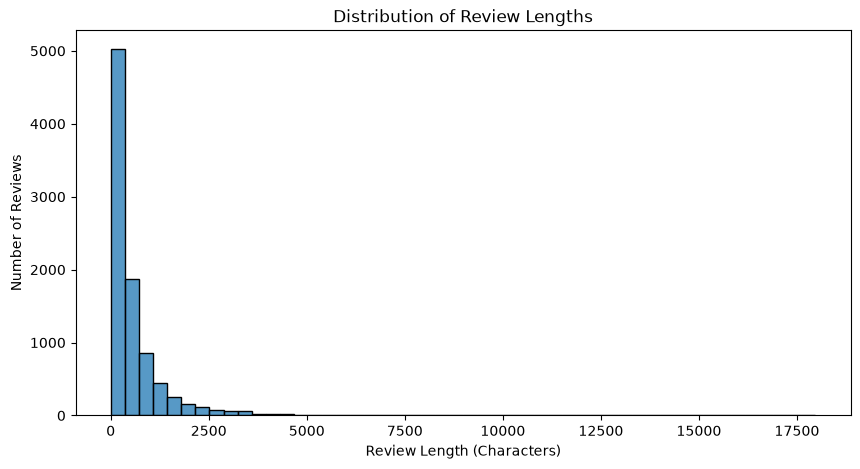

In [30]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_reviews["review_chars"],
    bins=50
)

plt.title("Distribution of Review Lengths")
plt.xlabel("Review Length (Characters)")
plt.ylabel("Number of Reviews")

plt.show()

In [31]:
reviews_per_product = (
    df_reviews
    .groupby(["product_id", "productName"])
    .size()
    .reset_index(name="review_count")
    .sort_values("review_count", ascending=False)
)

display(reviews_per_product.head(20))

,product_id,productName,review_count
798,812,"Pocket Guitar Chord Practice Tool, Portable Guitar Neck for Trainer Beginner w/a Rotatable Chords Chart Screen Battery Included",13
2,4,"Wireless Earbuds Bluetooth Headphones, 54H Playtime Stereo Over Ear Buds with ENC Noise Cancelling, LED Power Display, IPX7 Waterproof Sport Earphones with Earhooks for Running/Workouts (Black)",13
806,820,YAMAHA MG10XU 10-Input Stereo Mixer with Effects,13
807,822,"Vangoa Classical Guitar 3/4 Inch Acoustic Classical Guitar, 36 Inch Junior Size Nylon String Guitar Bundle Kit for Beginner Teens, Cedar Top",13
811,826,"40/41/42"" Acoustic Guitar Bag,Oxford Fabric with 0.35"" Thick Padding",13
812,827,"Pyle 30-Inch Beginner Acoustic Guitar Kit, 6-String Classical Style Travel Guitar for Kids & Adults - Includes Shoulder Strap, Strings, Picks, Tuning Pitch Pipe & Storage Gig Bag - Handcrafted Wood",13
813,828,Washburn Bella Tono Vite S9V Studio Cutaway Acoustic Electric Guitar (BTS9VCECH-D),13
814,829,"D'Addario Pro-Arte Nylon Classical Guitar Strings, Normal Tension",13
672,684,"Bath & Body Works 3-Wick Candle, Eucalyptus Spearmint, Soy Wax Blend",13
669,681,"Yankee Candle MidSummer's Night Scented Candle, 22oz Large Jar",13


In [32]:
reviews_per_category = (
    df_reviews
    .groupby("category")
    .size()
    .sort_values(ascending=False)
)

display(reviews_per_category)

category
electric toothbrush        580
sunglasses                 563
sneakers                   550
coffee maker               539
candle                     537
water bottle               527
kitchen knife set          522
yamaha accoustic guitar    505
notebook journal           501
desk lamp LED              490
gaming chair               484
t-shirt                    482
instant pot                195
air purifier               191
mechanical keyboard        188
smartwatch                 187
backpack                   185
phone case                 183
USB-C hub                  179
bluetooth speaker          178
DSLR camera                177
gaming mouse               173
phone stand                172
webcam HD                  171
monitor 27 inch            160
portable charger           154
budget laptop              141
wireless earbuds           129
dtype: int64

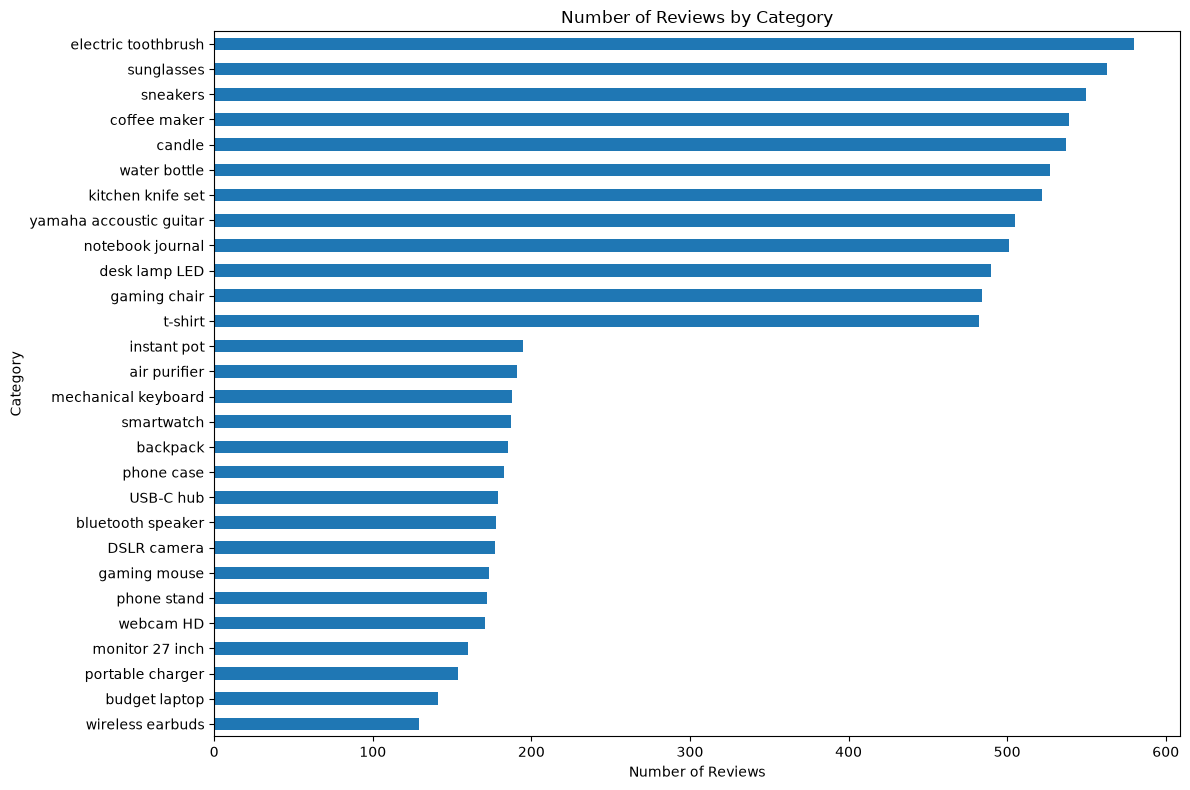

In [33]:
plt.figure(figsize=(12, 8))

reviews_per_category.sort_values().plot(
    kind="barh"
)

plt.title("Number of Reviews by Category")
plt.xlabel("Number of Reviews")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [34]:
unique_products = df_reviews["product_id"].nunique()

print("Number of unique products:", unique_products)
print("Total reviews:", len(df_reviews))

Number of unique products: 817
Total reviews: 9043


In [35]:
display(
    reviews_per_product["review_count"].describe()
)

count    817.000000
mean      11.068543
std        2.160860
min        1.000000
25%        9.000000
50%       12.000000
75%       13.000000
max       13.000000
Name: review_count, dtype: float64

In [36]:
duplicate_within_product = (
    df_reviews.duplicated(
        subset=["product_id", "review"]
    ).sum()
)

print(
    "Duplicate reviews within the same product:",
    duplicate_within_product
)

Duplicate reviews within the same product: 1


In [37]:
duplicate_mask = df_reviews.duplicated(
    subset=["product_id", "review"],
    keep=False
)

display(
    df_reviews.loc[
        duplicate_mask,
        ["product_id", "review_id", "productName", "review"]
    ]
)

,product_id,review_id,productName,review
7465,690,690_2,"Bath & Body Works 3-Wick Candle, Champagne Toast, Soy Wax Blend",It smells delicious
7467,690,690_4,"Bath & Body Works 3-Wick Candle, Champagne Toast, Soy Wax Blend",It smells delicious


In [38]:
before = len(df_reviews)

df_reviews = df_reviews.drop_duplicates(
    subset=["product_id", "review"],
    keep="first"
).reset_index(drop=True)

after = len(df_reviews)

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

Rows before: 9043
Rows after: 9042
Rows removed: 1


In [39]:
FLAT_REVIEWS_PATH = Path(
    "artifacts/feature_b/flattened_reviews.csv"
)

df_reviews.to_csv(
    FLAT_REVIEWS_PATH,
    index=False
)

print(
    f"Updated flattened dataset saved to: "
    f"{FLAT_REVIEWS_PATH}"
)

Updated flattened dataset saved to: artifacts\feature_b\flattened_reviews.csv


In [40]:
html_tag_count = df_reviews["review"].str.contains(
    r"<[^>]+>",
    regex=True,
    na=False
).sum()

url_count = df_reviews["review"].str.contains(
    r"https?://\S+|www\.\S+",
    regex=True,
    na=False
).sum()

html_entity_count = df_reviews["review"].str.contains(
    r"&[a-zA-Z]+;",
    regex=True,
    na=False
).sum()

print("Reviews containing HTML tags:", html_tag_count)
print("Reviews containing URLs:", url_count)
print("Reviews containing HTML entities:", html_entity_count)

Reviews containing HTML tags: 2
Reviews containing URLs: 13
Reviews containing HTML entities: 0


In [41]:
def clean_review(text):
    text = str(text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Replace URLs with a placeholder
    text = re.sub(
        r"https?://\S+|www\.\S+",
        " URL ",
        text
    )

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


df_reviews["review_clean"] = (
    df_reviews["review"]
    .map(clean_review)
)

display(
    df_reviews[
        ["review", "review_clean"]
    ].head(10)
)

,review,review_clean
0,"I really like the understated, stylish design, but what impressed me most is how comfortable they are to wear. That's something I really have to praise—I would already be very happy with them just...","I really like the understated, stylish design, but what impressed me most is how comfortable they are to wear. That's something I really have to praise—I would already be very happy with them just..."
1,"I really love these earbuds. I use them every day during my lunch break, and my ears never hurt even after wearing them for a long time. They also have a translation feature, which can definitely ...","I really love these earbuds. I use them every day during my lunch break, and my ears never hurt even after wearing them for a long time. They also have a translation feature, which can definitely ..."
2,"These are now the earbuds I use most often every day. I really don't like noisy environments, and these have been a great fit for me. I can enjoy my music without being bothered by all the surroun...","These are now the earbuds I use most often every day. I really don't like noisy environments, and these have been a great fit for me. I can enjoy my music without being bothered by all the surroun..."
3,"These earbuds are incredibly small and comfortable, even when sleeping on my side. The soft silicone feels gentle and doesn't put any pressure on my ears. I often use them before bed to listen to ...","These earbuds are incredibly small and comfortable, even when sleeping on my side. The soft silicone feels gentle and doesn't put any pressure on my ears. I often use them before bed to listen to ..."
4,"These headphones exceeded my expectations. They're very easy to connect via Bluetooth, and the sound is clear, with good volume and pleasant bass. The battery lasts a long time, and the charging c...","These headphones exceeded my expectations. They're very easy to connect via Bluetooth, and the sound is clear, with good volume and pleasant bass. The battery lasts a long time, and the charging c..."
5,"I’m very happy with these wireless earbuds. The sound quality is clear, with great bass, and the Bluetooth connection is quick and stable. They are comfortable to wear for long periods, and the LE...","I’m very happy with these wireless earbuds. The sound quality is clear, with great bass, and the Bluetooth connection is quick and stable. They are comfortable to wear for long periods, and the LE..."
6,"These wireless earbuds exceeded my expectations. The sound is clear, with deep bass and crisp highs, making music and calls sound great. They pair quickly with Bluetooth 5.4 and maintain a stable ...","These wireless earbuds exceeded my expectations. The sound is clear, with deep bass and crisp highs, making music and calls sound great. They pair quickly with Bluetooth 5.4 and maintain a stable ..."
7,"I really like these wireless earbuds. They connect quickly via Bluetooth, the sound is clear, and the volume is great. They are comfortable to wear, and the charging case is compact and easy to ca...","I really like these wireless earbuds. They connect quickly via Bluetooth, the sound is clear, and the volume is great. They are comfortable to wear, and the charging case is compact and easy to ca..."
8,"Great sound quality and excellent battery life!I was pleasantly surprised by the quality of these S66 wireless earbuds. They connected to my phone quickly and easily, and the sound is clear with g...","Great sound quality and excellent battery life!I was pleasantly surprised by the quality of these S66 wireless earbuds. They connected to my phone quickly and easily, and the sound is clear with g..."
9,"These earbuds work really well! The sound is clear, the bass is great, and they connect quickly to Bluetooth. They are comfortable to wear and the battery lasts a long time. The charging case is c...","These earbuds work really well! The sound is clear, the bass is great, and they connect quickly to Bluetooth. They are c

In [42]:
empty_clean_reviews = (
    df_reviews["review_clean"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print(
    "Empty reviews after cleaning:",
    empty_clean_reviews
)

Empty reviews after cleaning: 0


In [43]:
short_reviews = df_reviews[
    df_reviews["review_clean"].str.len() <= 10
][
    ["review_id", "productName", "review_clean"]
]

print(
    "Reviews with 10 or fewer characters:",
    len(short_reviews)
)

display(short_reviews.head(30))

Reviews with 10 or fewer characters: 114


,review_id,productName,review_clean
13,3_9,"XIAOWTEK Wireless Earbuds, 2026 Bluetooth 5.4 Headphones Bass Stereo Ear Buds with Noise Cancelling Mic, LED Display in Ear Earphones 50H Playtime Ear Buds, IP7 Waterproof for Laptop Pad Phones White",All.
48,7_11,"Wireless Earbuds, Smart Touchscreen Ear Buds, ANC Headphones, Bluetooth 5.4",excellent
201,22_9,"Razer Viper V3 HyperSpeed Wireless PC Gaming Mouse, 82g, Black",Very good
489,48_8,"AULA F75 Pro Wireless Mechanical Keyboard,75% Hot Swappable Custom Keyboard with Knob,RGB Backlit,Pre-lubed Reaper Switches,Side Printed PBT Keycaps,2.4GHz/USB-C/BT5.0 Mechanical Gaming Keyboards",Good
502,49_8,Logitech G413 SE Full-Size Mechanical Gaming Keyboard - Black,Very good
548,53_8,"AULA S99 Gaming Keyboard, Wireless Green Creamy Computer Keyboards",Original 💯
767,72_11,"Amazfit Bip 6 Smart Watch, 1.97"" AMOLED Display, GPS, iOS/Android",Optimal
800,75_8,"SAMSUNG Galaxy FIT 3 [2024] 1.6"" AMOLED Display | 14 Days Battery Life | 100+ Watchfaces | 100+ Exercise Modes | International Model - (Gray)",nice
816,76_11,"Samsung Galaxy Watch 8 (2025), Graphite, 40mm, Bluetooth Smartwatch",It’s good
853,79_10,"Samsung Galaxy Watch 8 (2025), Graphite, 44mm, Bluetooth Smartwatch",excellent


In [44]:
extremely_short = df_reviews[
    df_reviews["review_clean"].str.len() <= 3
][
    ["review_id", "productName", "review_clean"]
]

print(
    "Reviews with 3 or fewer characters:",
    len(extremely_short)
)

display(extremely_short)

Reviews with 3 or fewer characters: 1


,review_id,productName,review_clean
8532,783_7,"COOPER ChatStand Sturdy Cell Phone Holder, iPhone Stand for Desk, Recording",Top


In [45]:
print("Total reviews:", len(df_reviews))
print(
    "Missing cleaned reviews:",
    df_reviews["review_clean"].isna().sum()
)
print(
    "Blank cleaned reviews:",
    df_reviews["review_clean"].str.strip().eq("").sum()
)

Total reviews: 9042
Missing cleaned reviews: 0
Blank cleaned reviews: 0


In [46]:
category_length_stats = (
    df_reviews
    .groupby("category")
    .agg(
        review_count=("review_clean", "size"),
        avg_chars=("review_chars", "mean"),
        median_chars=("review_chars", "median"),
        avg_words=("review_words", "mean")
    )
    .sort_values("review_count", ascending=False)
)

display(category_length_stats)

,review_count,avg_chars,median_chars,avg_words
category,,,,
electric toothbrush,580,628.079310,389.0,112.646552
sunglasses,563,325.127886,194.0,58.055062
sneakers,550,335.536364,200.5,61.516364
coffee maker,539,893.721707,463.0,164.165121
candle,536,264.884328,128.0,47.591418
water bottle,527,594.715370,401.0,110.239089
kitchen knife set,522,398.419540,197.0,70.998084
yamaha accoustic guitar,505,567.071287,261.0,104.116832
notebook journal,501,408.790419,254.0,73.229541


In [47]:
sentiment_definitions = {
    "positive": (
        "The review expresses satisfaction, praise, recommendation, "
        "or clearly favorable feelings toward the product."
    ),
    "neutral": (
        "The review is mainly factual, descriptive, mixed without a clear "
        "overall sentiment, or does not express a clearly positive or negative opinion."
    ),
    "negative": (
        "The review expresses dissatisfaction, criticism, disappointment, "
        "a problem, or clearly unfavorable feelings toward the product."
    )
}

for label, definition in sentiment_definitions.items():
    print(f"{label.upper()}: {definition}")

POSITIVE: The review expresses satisfaction, praise, recommendation, or clearly favorable feelings toward the product.
NEUTRAL: The review is mainly factual, descriptive, mixed without a clear overall sentiment, or does not express a clearly positive or negative opinion.
NEGATIVE: The review expresses dissatisfaction, criticism, disappointment, a problem, or clearly unfavorable feelings toward the product.


In [48]:
import os
from dotenv import load_dotenv

load_dotenv("environment.env")

api_key = os.getenv("GEMINI_API_KEY")

print("Gemini API key found:", api_key is not None)

Gemini API key found: True


In [49]:
from google import genai

client = genai.Client(api_key=api_key)

print("Gemini client initialized.")

Gemini client initialized.


In [50]:
test_review = df_reviews["review_clean"].iloc[0]

response = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=f"""
Classify this Amazon review as exactly one of:
positive, neutral, negative.

Definitions:
- positive: expresses satisfaction, praise, or favorable feelings.
- neutral: mainly factual/descriptive, mixed without a clear overall sentiment,
  or does not express a clear positive or negative opinion.
- negative: expresses dissatisfaction, criticism, disappointment, or unfavorable feelings.

Review:
{test_review}

Return only the label.
"""
)

print("Review:", test_review)
print("Gemini:", response.text.strip())

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


ClientError: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.5-flash\nPlease retry in 16.070975229s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini-3.5-flash'},

In [ ]:
import json

test_review = df_reviews["review_clean"].iloc[0]

response = client.models.generate_content(
    model="gemini-3.8-flash",
    contents=f"""
Classify this Amazon review into exactly one sentiment:
positive, neutral, or negative.

Definitions:
- positive: expresses satisfaction, praise, or favorable feelings.
- neutral: mainly factual/descriptive, mixed without a clear overall sentiment,
  or does not express a clear positive or negative opinion.
- negative: expresses dissatisfaction, criticism, disappointment, or unfavorable feelings.

Return ONLY valid JSON in this exact format:
{{"sentiment": "positive"}}

Review:
{test_review}
"""
)

print(response.text)

{"sentiment": "positive"}


In [ ]:
async def classify_review(review, max_retries=5):
    for attempt in range(max_retries):
        try:
            async with semaphore:
                response = await client.aio.models.generate_content(
                    model="Gemini 3.1 Flash image",
                    contents=f"""
Classify this Amazon review into exactly one sentiment:
positive, neutral, or negative.

Definitions:
- positive: expresses satisfaction, praise, or favorable feelings.
- neutral: mainly factual/descriptive, mixed without a clear overall sentiment,
  or does not express a clear positive or negative opinion.
- negative: expresses dissatisfaction, criticism, disappointment, or unfavorable feelings.

Return ONLY valid JSON in this exact format:
{{"sentiment": "positive"}}

Review:
{review}
"""
                )

            result = json.loads(response.text.strip())
            sentiment = result.get("sentiment")

            if sentiment in {"positive", "neutral", "negative"}:
                return sentiment

            return None

        except json.JSONDecodeError:
            # Gemini returned something that was not valid JSON
            return None

        except Exception as error:
            if attempt == max_retries - 1:
                print(f"Failed review after {max_retries} attempts: {error}")
                return None

            await asyncio.sleep(2 ** attempt)

In [ ]:
test_reviews = df_reviews["review_clean"].head(5).tolist()

results = await asyncio.gather(
    *(classify_review(review) for review in test_reviews)
)

for review, sentiment in zip(test_reviews, results):
    print(f"Review: {review[:100]}...")
    print(f"Sentiment: {sentiment}")
    print("-" * 80)

Review: I really like the understated, stylish design, but what impressed me most is how comfortable they ar...
Sentiment: positive
--------------------------------------------------------------------------------
Review: I really love these earbuds. I use them every day during my lunch break, and my ears never hurt even...
Sentiment: positive
--------------------------------------------------------------------------------
Review: These are now the earbuds I use most often every day. I really don't like noisy environments, and th...
Sentiment: positive
--------------------------------------------------------------------------------
Review: These earbuds are incredibly small and comfortable, even when sleeping on my side. The soft silicone...
Sentiment: positive
--------------------------------------------------------------------------------
Review: These headphones exceeded my expectations. They're very easy to connect via Bluetooth, and the sound...
Sentiment: positive
----------------

In [ ]:
if "sentiment" not in df_reviews.columns:
    df_reviews["sentiment"] = pd.NA

print("Reviews already labeled:", df_reviews["sentiment"].notna().sum())
print("Reviews remaining:", df_reviews["sentiment"].isna().sum())

Reviews already labeled: 4
Reviews remaining: 9038


In [ ]:
async def label_batch(reviews):
    tasks = [
        classify_review(review)
        for review in reviews
    ]

    return await asyncio.gather(*tasks)

In [ ]:
batch_size = 20

total_reviews = len(df_reviews)
total_batches = (total_reviews + batch_size - 1) // batch_size

for batch_number, start in enumerate(
    range(0, total_reviews, batch_size), start=1
):
    end = min(start + batch_size, total_reviews)

    batch_indices = df_reviews.index[start:end]

    # Only process reviews that don't have a label yet
    batch_indices = batch_indices[
        df_reviews.loc[batch_indices, "sentiment"].isna()
    ]

    if len(batch_indices) == 0:
        print(f"Batch {batch_number}/{total_batches}: already completed")
        continue

    batch_reviews = df_reviews.loc[
        batch_indices, "review_clean"
    ].tolist()

    print(
        f"\nBatch {batch_number}/{total_batches} "
        f"- processing {len(batch_reviews)} reviews"
    )

    batch_results = await label_batch(batch_reviews)

    df_reviews.loc[
        batch_indices, "sentiment"
    ] = batch_results

    # Save after every batch
    df_reviews.to_csv(FLAT_REVIEWS_PATH, index=False)

    labeled = df_reviews["sentiment"].notna().sum()
    failed = df_reviews["sentiment"].isna().sum()

    print(f"Saved progress: {labeled}/{total_reviews}")
    print(f"Remaining: {failed}")

Batch 1/453: already completed
Batch 2/453: already completed
Batch 3/453: already completed

Batch 4/453 - processing 18 reviews
Failed review after 5 attempts: 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': '* GenerateContentRequest.model: unexpected model name format\n', 'status': 'INVALID_ARGUMENT'}}
Failed review after 5 attempts: 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': '* GenerateContentRequest.model: unexpected model name format\n', 'status': 'INVALID_ARGUMENT'}}
Failed review after 5 attempts: 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': '* GenerateContentRequest.model: unexpected model name format\n', 'status': 'INVALID_ARGUMENT'}}
Failed review after 5 attempts: 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': '* GenerateContentRequest.model: unexpected model name format\n', 'status': 'INVALID_ARGUMENT'}}
Failed review after 5 attempts: 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': '* GenerateContentRequest.model: unex

CancelledError: 

In [53]:
df_reviews = pd.read_csv("artifacts/feature_b/flattened_reviews_labeled.csv")

print("Total reviews:", len(df_reviews))
print("\nSentiment distribution:")
print(df_reviews["sentiment"].value_counts())

Total reviews: 9042

Sentiment distribution:
sentiment
positive    7763
neutral      840
negative     439
Name: count, dtype: int64


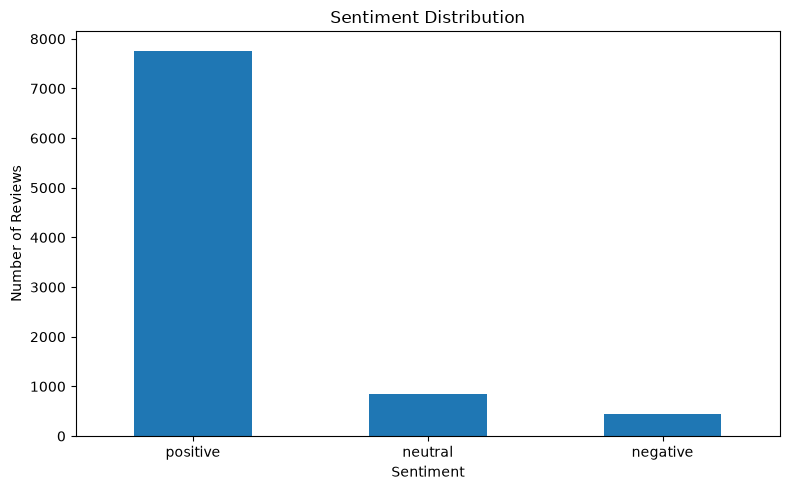

In [54]:
sentiment_counts = df_reviews["sentiment"].value_counts()

plt.figure(figsize=(8, 5))
sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [55]:
X = df_reviews["review_clean"]
y = df_reviews["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

Training reviews: 7233
Testing reviews: 1809

Training distribution:
sentiment
positive    6210
neutral      672
negative     351
Name: count, dtype: int64

Testing distribution:
sentiment
positive    1553
neutral      168
negative      88
Name: count, dtype: int64


In [56]:
baseline_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=SEED
        )
    )
])

baseline_model.fit(X_train, y_train)

print("Baseline model trained.")

Baseline model trained.


In [57]:
y_pred = baseline_model.predict(X_test)

print("Classification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        labels=["positive", "neutral", "negative"],
        digits=4
    )
)

Classification Report:

              precision    recall  f1-score   support

    positive     0.9597    0.9665    0.9631      1553
     neutral     0.6287    0.6250    0.6269       168
    negative     0.6026    0.5341    0.5663        88

    accuracy                         0.9138      1809
   macro avg     0.7303    0.7085    0.7187      1809
weighted avg     0.9116    0.9138    0.9126      1809



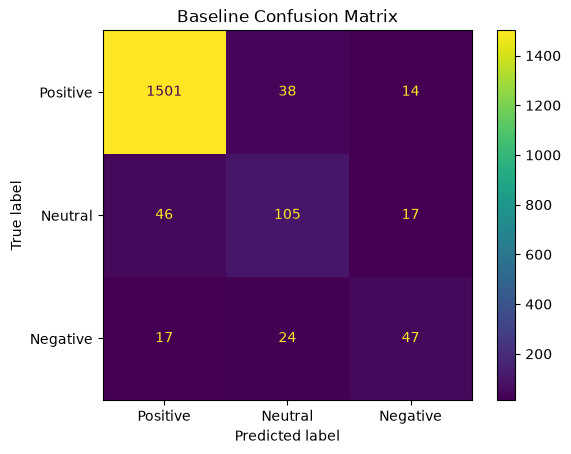

In [58]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["positive", "neutral", "negative"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Positive", "Neutral", "Negative"]
)

disp.plot()
plt.title("Baseline Confusion Matrix")
plt.show()

In [59]:
svm_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LinearSVC(
            class_weight="balanced",
            random_state=SEED
        )
    )
])

svm_model.fit(X_train, y_train)

print("SVM model trained.")

SVM model trained.


In [60]:
y_pred_svm = svm_model.predict(X_test)

print("SVM Classification Report:\n")
print(
    classification_report(
        y_test,
        y_pred_svm,
        labels=["positive", "neutral", "negative"],
        digits=4
    )
)

SVM Classification Report:

              precision    recall  f1-score   support

    positive     0.9251    0.9936    0.9581      1553
     neutral     0.7234    0.4048    0.5191       168
    negative     0.8511    0.4545    0.5926        88

    accuracy                         0.9127      1809
   macro avg     0.8332    0.6176    0.6899      1809
weighted avg     0.9027    0.9127    0.8995      1809

